<a href="https://colab.research.google.com/github/AnjanaGunarathna/DL_News_Detection/blob/Dinidi(BiLSTM)/fake_news_bi_lstm_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 2) Imports and reproducibility
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
# Upload kaggle.json and download dataset automatically
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!mkdir -p ./data
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset -p ./data
!unzip -q ./data/fake-and-real-news-dataset.zip -d ./data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
  0% 0.00/41.0M [00:00<?, ?B/s]
100% 41.0M/41.0M [00:00<00:00, 2.24GB/s]


In [ ]:
# 3) Load CSVs
fake_path = './data/Fake.csv'
true_path = './data/True.csv'

if not (os.path.exists(fake_path) and os.path.exists(true_path)):
  raise FileNotFoundError('Expected data/Fake.csv and data/True.csv. Download the Kaggle dataset and unzip to ./data')

df_fake = pd.read_csv(fake_path)
df_true = pd.read_csv(true_path)


print('Fake shape:', df_fake.shape)
print('True shape:', df_true.shape)


# quick peek
print(df_fake.columns)
print(df_true.columns)

Fake shape: (23481, 4)
True shape: (21417, 4)
Index(['title', 'text', 'subject', 'date'], dtype='object')
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [ ]:
# 4) Combine and label
df_fake['label'] = 1 # 1 = fake
df_true['label'] = 0 # 0 = real


# keep only useful columns (title + text are useful). We'll use 'text' primarily.
for col in ['title','text','subject','date','label']:
  if col not in df_fake.columns:
    print('Warning: column',col,'missing in Fake.csv')


df = pd.concat([df_fake[['title','text','label']], df_true[['title','text','label']]], axis=0).reset_index(drop=True)
print('Combined shape:', df.shape)


# shuffle
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

Combined shape: (44898, 3)


label
1    23481
0    21417
Name: count, dtype: int64
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   

                                                text  label  
0  21st Century Wire says Ben Stein, reputable pr...      1  
1  WASHINGTON (Reuters) - U.S. President Donald T...      0  
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...      0  


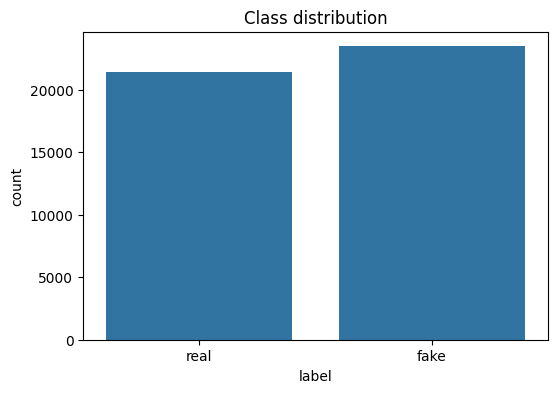

In [ ]:
# 5) Quick EDA
print(df['label'].value_counts())
print(df.head(3))


plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.xticks([0,1], ['real','fake'])
plt.title('Class distribution')
plt.show()

In [ ]:
import re

# List of common publishers to remove
publishers = ["Reuters", "CNN", "BBC", "NYT", "Fox News", "NBC", "AP", "Washington Post", "CBS"]

def clean_text(text):
    # Remove publisher names (case-insensitive)
    for pub in publishers:
        text = re.sub(rf'\b{pub}\b', '', text, flags=re.IGNORECASE)

    # Remove dates in formats like "31-Dec-17", "Dec 28, 2017", "12/31/17"
    text = re.sub(r'\b\d{1,2}[-/][A-Za-z]{3,}[-/]\d{2,4}\b', '', text)
    text = re.sub(r'\b[A-Za-z]{3,}\s\d{1,2},\s\d{4}\b', '', text)

    # Remove extra whitespaces and leftover punctuation from removal
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Example usage:
sample_text = "WASHINGTON (Reuters) - Transgender people will be allowed for the first time..."
cleaned = clean_text(sample_text)
print(cleaned)


WASHINGTON () - Transgender people will be allowed for the first time...


In [ ]:
# 6) Text cleaning / preprocessing
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
STOP = set(stopwords.words('english'))


def clean_text(text, remove_stopwords=True):
  text = str(text)
  text = text.lower()
  text = re.sub(r'\n', ' ', text)
  text = re.sub(r"http\S+|www\S+", ' ', text) # remove urls
  text = re.sub(r'[^a-z ]', ' ', text)
  tokens = text.split()
  if remove_stopwords:
    tokens = [t for t in tokens if t not in STOP]
  return ' '.join(tokens)


# apply (may take a minute)
df['clean_text'] = df['text'].astype(str).apply(lambda x: clean_text(x, remove_stopwords=True))


# quick check
print(df['clean_text'].str.len().describe())
print(df.loc[0, 'clean_text'][:300])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


count    44898.000000
mean      1722.097087
std       1533.043181
min          0.000000
25%        860.250000
50%       1506.000000
75%       2153.000000
max      38855.000000
Name: clean_text, dtype: float64
st century wire says ben stein reputable professor pepperdine university also hollywood fame appearing tv shows films ferris bueller day made provocative statements judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement th circuit co


In [ ]:
# 7) Baseline: TF-IDF + Logistic Regression (fast baseline)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


X = df['clean_text']
y = df['label'].values


# train/test split (stratified)
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)


tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)


preds_lr = lr.predict(X_test_tfidf)
print('\nBaseline (TF-IDF + LR) classification report:\n')
print(classification_report(y_test, preds_lr, digits=4))
print('ROC-AUC:', roc_auc_score(y_test, lr.predict_proba(X_test_tfidf)[:,1]))


# Save baseline artifacts
import pickle
os.makedirs('./artifacts', exist_ok=True)
with open('./artifacts/tfidf.pkl','wb') as f:
  pickle.dump(tfidf, f)
with open('./artifacts/lr_model.pkl','wb') as f:
  pickle.dump(lr, f)


Baseline (TF-IDF + LR) classification report:

              precision    recall  f1-score   support

           0     0.9833    0.9916    0.9874      4284
           1     0.9923    0.9847    0.9885      4696

    accuracy                         0.9880      8980
   macro avg     0.9878    0.9881    0.9880      8980
weighted avg     0.9880    0.9880    0.9880      8980

ROC-AUC: 0.9991353369854472


In [ ]:
# 8) Prepare data for deep learning (tokenize + pad)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


MAX_VOCAB = 20000
MAX_LEN = 300
EMBEDDING_DIM = 100


tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text) # fit only on training set to avoid leakage


X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)


X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')


print('X_train_pad shape:', X_train_pad.shape)


# save tokenizer
with open('./artifacts/tokenizer.pkl','wb') as f:
  pickle.dump(tokenizer, f)

X_train_pad shape: (35918, 300)


In [ ]:
# 9)Load GloVe embeddings and build embedding matrix
!mkdir -p ./embeddings
!wget http://nlp.stanford.edu/data/glove.6B.zip -P ./embeddings
!unzip -q ./embeddings/glove.6B.zip -d ./embeddings

# After you have glove.6B.100d.txt in ./embeddings, run the code below.
EMBEDDING_PATH = './embeddings/glove.6B.100d.txt' # change path if needed
use_glove = os.path.exists(EMBEDDING_PATH)


if use_glove:
  import numpy as np
  embeddings_index = {}
  with open(EMBEDDING_PATH, 'r', encoding='utf8') as f:
    for line in f:
      values = line.split()
      word = values[0]
      coefs = np.asarray(values[1:], dtype='float32')
      embeddings_index[word] = coefs
    print('Loaded %d word vectors.' % len(embeddings_index))


word_index = tokenizer.word_index
nb_words = min(MAX_VOCAB, len(word_index) + 1)
embedding_matrix = np.zeros((nb_words, EMBEDDING_DIM))
for word, i in word_index.items():
  if i >= nb_words:
    continue
  embedding_vector = embeddings_index.get(word)
  if embedding_vector is not None:
    embedding_matrix[i] = embedding_vector
  print('Embedding matrix shape:', embedding_matrix.shape)
else:
  print('GloVe not found in', EMBEDDING_PATH, '- training embeddings from scratch.')

Streaming output truncated to the last 5000 lines.
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: 

In [ ]:
# 10) Build BiLSTM model (Keras)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam


vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)


model = Sequential()
if use_glove:
  model.add(Embedding(vocab_size, EMBEDDING_DIM, weights=[embedding_matrix], input_length=MAX_LEN, trainable=False))
else:
  model.add(Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_LEN))


model.add(SpatialDropout1D(0.3))
model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))


model.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])
model.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])
model.build(input_shape=(None, MAX_LEN))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 300, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,251,009 (8.59 MB)

 Trainable params: 251,009 (980.50 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

In [ ]:
# 11) Train (with callbacks)
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
mc = ModelCheckpoint('./artifacts/best_bilstm.h5', monitor='val_loss', save_best_only=True)


history = model.fit(X_train_pad, y_train, batch_size=128, epochs=8, validation_split=0.1, callbacks=[es, mc])

Epoch 1/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9398 - loss: 0.1618

253/253 ━━━━━━━━━━━━━━━━━━━━ 508s 2s/step - accuracy: 0.9399 - loss: 0.1615 - val_accuracy: 0.9981 - val_loss: 0.0078
Epoch 2/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9966 - loss: 0.0141

253/253 ━━━━━━━━━━━━━━━━━━━━ 450s 2s/step - accuracy: 0.9966 - loss: 0.0141 - val_accuracy: 0.9983 - val_loss: 0.0068
Epoch 3/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9982 - loss: 0.0073

253/253 ━━━━━━━━━━━━━━━━━━━━ 452s 2s/step - accuracy: 0.9982 - loss: 0.0073 - val_accuracy: 0.9986 - val_loss: 0.0054
Epoch 4/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 447s 2s/step - accuracy: 0.9982 - loss: 0.0071 - val_accuracy: 0.9986 - val_loss: 0.0063
Epoch 5/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9984 - loss: 0.0063

253/253 ━━━━━━━━━━━━━━━━━━━━ 511s 2s/step - accuracy: 0.9984 - loss: 0.0063 - val_accuracy: 0.9989 - val_loss: 0.0048
Epoch 6/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9987 - loss: 0.0054

253/253 ━━━━━━━━━━━━━━━━━━━━ 491s 2s/step - accuracy: 0.9987 - loss: 0.0054 - val_accuracy: 0.9986 - val_loss: 0.0047
Epoch 7/8
238/253 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9989 - loss: 0.0049

36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step

BiLSTM classification report:

              precision    recall  f1-score   support

           0     0.9995    0.9972    0.9984      4284
           1     0.9975    0.9996    0.9985      4696

    accuracy                         0.9984      8980
   macro avg     0.9985    0.9984    0.9984      8980
weighted avg     0.9984    0.9984    0.9984      8980

ROC-AUC: 0.9998967822506629
*********************************************************************************************
Training Accuracy: 99.94%
Training Loss: 0.20%
-----------------------------------------------------------
Testing Accuracy: 99.84%
Testing Loss: 0.76%
*********************************************************************************************


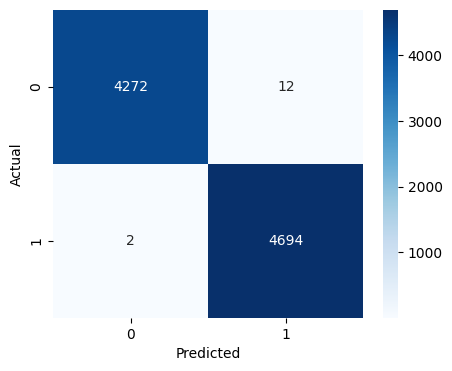

In [ ]:
# 12) Evaluate
pred_probs = model.predict(X_test_pad, batch_size=256)
preds = (pred_probs >= 0.5).astype(int).reshape(-1)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print('\nBiLSTM classification report:\n')
print(classification_report(y_test, preds, digits=4))
print('ROC-AUC:', roc_auc_score(y_test, pred_probs))

# Evaluate model on train and test sets
train_loss, train_acc = model.evaluate(X_train_pad, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)

# Convert to percentages
train_acc *= 100
test_acc *= 100
train_loss *= 100
test_loss *= 100

print("*********************************************************************************************")
print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Training Loss: {train_loss:.2f}%")
print("-----------------------------------------------------------")
print(f"Testing Accuracy: {test_acc:.2f}%")
print(f"Testing Loss: {test_loss:.2f}%")
print("*********************************************************************************************")

# Confusion matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

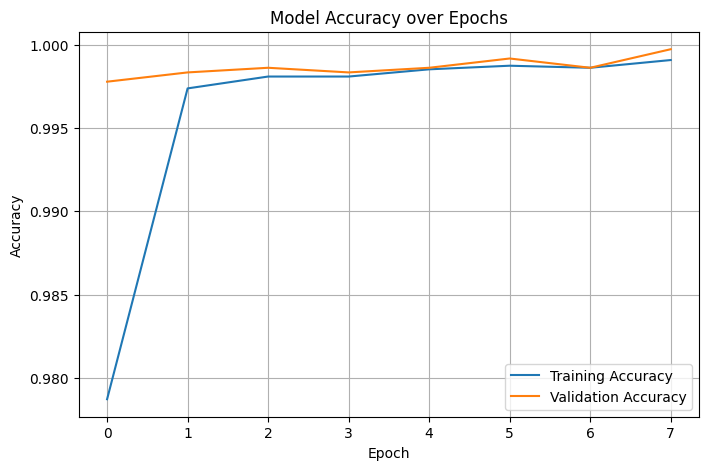

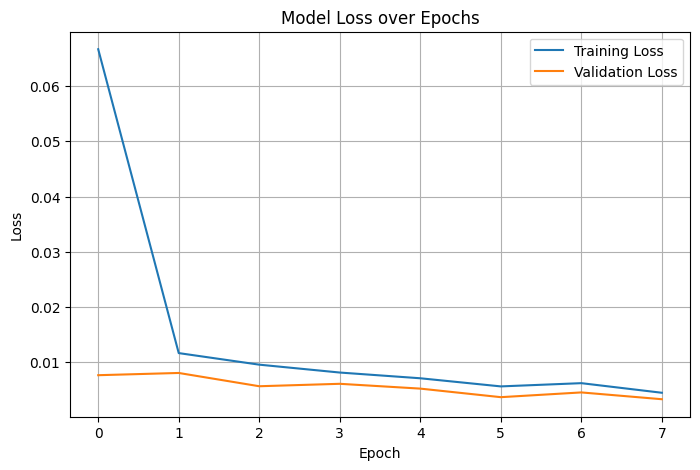

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# Plot Training & Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [ ]:
# Interactive testing cell — paste this into Colab and run it
# Requires: ./artifacts/tokenizer.pkl and ./artifacts/bilstm_model.h5 or ./artifacts/bilstm_model.keras

import os
import pickle
import re
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
import numpy as np

# Ensure NLTK stopwords are available
nltk.download('stopwords', quiet=True)
STOP = set(stopwords.words('english'))

# --- Load tokenizer ---
tk_path = './artifacts/tokenizer.pkl'
if not os.path.exists(tk_path):
    raise FileNotFoundError(f"Tokenizer not found at {tk_path}. Make sure tokenizer.pkl is in ./artifacts")

with open(tk_path, 'rb') as f:
    tokenizer = pickle.load(f)

# --- Load model (try .keras then .h5) ---
model = None
for candidate in ['./artifacts/bilstm_model.keras', './artifacts/bilstm_model.h5', './artifacts/best_bilstm.h5']:
    if os.path.exists(candidate):
        print(f"Loading model from: {candidate}")
        model = load_model(candidate)
        break
if model is None:
    raise FileNotFoundError("No model file found in ./artifacts. Expected bilstm_model.keras or bilstm_model.h5")

# Use same MAX_LEN you trained with
MAX_LEN = 300

# Cleaning function (must match training preprocessing)
def clean_text(text, remove_stopwords=True):
    text = str(text).lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r'[^a-z ]', " ", text)
    tokens = text.split()
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP]
    return " ".join(tokens)

# Prediction helper
def predict_article(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = model.predict(pad, verbose=0)
    # model.predict returns shape (1,1) or (1,) depending on Keras version
    prob_val = float(np.squeeze(prob))
    label = "Fake" if prob_val >= 0.5 else "Real"
    return label, prob_val

# --- Interactive loop: enter headlines one-by-one ---
print("Interactive Fake/Real tester\nType/paste a headline or article text and press Enter.\nLeave blank and press Enter to exit.\n")

while True:
    user_input = input("Enter headline/text (blank to quit): ").strip()
    if user_input == "":
        print("Exiting interactive tester.")
        break
    label, prob = predict_article(user_input)
    print(f"→ Prediction: {label} (confidence: {prob:.4f})\n")


Loading model from: ./artifacts/best_bilstm.h5
Interactive Fake/Real tester
Type/paste a headline or article text and press Enter.
Leave blank and press Enter to exit.

Enter headline/text (blank to quit): The U.S. House of Representatives on Thursday took a step toward averting a partial government shutdown at the end of this week, approving rules to debate a bill that would fund federal agencies through Jan. 19. Also cleared for debate was an $81 billion disaster aid bill to help U.S. states, Puerto Rico and the U.S. Virgin Islands recover from a series of recent natural disasters. House votes on both bills were expected later on Thursday. 
→ Prediction: Fake (confidence: 0.9965)

Enter headline/text (blank to quit):  WASHINGTON (Reuters) - The U.S. House of Representatives on Thursday took a step toward averting a partial government shutdown at the end of this week, approving rules to debate a bill that would fund federal agencies through Jan. 19. Also cleared for debate was an $81 